# Bộ phân loại hoạt động — quá trình huấn luyện và kết quả

**Notebook này chứng minh điều gì:** với 4 đặc trưng hiện tại (đều tính từ *độ lớn*
gia tốc cổ tay), model phân biệt tốt **nghỉ / đi bộ / chạy** nhưng **không thể** phân
biệt **nằm / ngồi / đứng** — và đó là giới hạn có nguyên nhân toán học, không phải lỗi
chọn model.

**Cách đọc:** mỗi phần có một câu hỏi ở đầu, code chạy để trả lời, rồi biểu đồ và nhận
xét. Không cần đọc code vẫn theo được mạch: đọc phần chữ và nhìn biểu đồ là đủ.

| Bước | Câu hỏi | Kết quả |
| :--- | :--- | :--- |
| 1 | Dữ liệu từ đâu ra? | 18 người, 16.880 cửa sổ dữ liệu sạch |
| 2 | 4 đặc trưng đo được gì? | Chỉ đo *cường độ* chuyển động, không đo *hướng* |
| 3 | Model đạt bao nhiêu trên 5 lớp? | 0.548 |
| 4 | Gộp 3 tư thế tĩnh lại thì sao? | 0.853 |
| 5 | Con số đó có thật sự tốt không? | Hơn baseline +0.347 và +0.254 |
| 6 | Model học được quy tắc gì? | Vẽ cây quyết định ra xem |

> Mọi kết quả dưới đây tái tạo được: `random_state=0` cố định, không có yếu tố ngẫu nhiên.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, confusion_matrix
import joblib, os

%matplotlib inline

IN_PATH  = "data/processed/master_dataset.csv"
OUT_PATH = "models/activity_classifier.pkl"
FEATURES = ["mean_mag", "std_mag", "peak_rel", "peak_max"]
ACTS_5CLASS = ["lying", "sitting", "standing", "walking", "running"]
ACTS_3CLASS = ["stationary", "walking", "running"]

# Static postures share one colour, dynamic activities another: the point of nearly
# every chart below is that this split is the only one the features can see.
C_STATIC, C_DYNAMIC, C_ACCENT = "#C2643B", "#2E6F95", "#1F3B63"
COLOR = {"lying": C_STATIC, "sitting": C_STATIC, "standing": C_STATIC,
         "stationary": C_STATIC, "walking": C_DYNAMIC, "running": C_DYNAMIC}

plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.titlesize": 12, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25})


def make_model():
    """Single definition so every run below is provably the same model."""
    return DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=0)

---
## Bước 1 — Dữ liệu đến từ đâu

Thiết bị đeo cổ tay ghi dữ liệu xuống bộ nhớ trong suốt phiên đo. Mỗi participant thực
hiện 5 hoạt động, mỗi hoạt động 90 giây. Thiết bị **tự tính 4 đặc trưng ngay trên
board** theo từng cửa sổ 2.4 giây rồi ghi lại — nên mỗi dòng trong bảng dưới là một
cửa sổ 2.4 giây, không phải một hoạt động.

**Loại bỏ dòng chuyển tiếp:** khoảng ~15 giây lúc participant đang đổi tư thế thì nhãn
ghi trong file chưa mô tả đúng việc cơ thể đang làm, nên các dòng đó bị loại. Giữ lại
sẽ đưa dữ liệu sai nhãn vào cả tập huấn luyện lẫn tập kiểm tra.

In [2]:
df_all = pd.read_csv(IN_PATH)
df = df_all[df_all["is_transition"] == 0].copy()

print(f"Tổng số dòng ghi được      : {len(df_all):,}")
print(f"Sau khi loại dòng chuyển tiếp: {len(df):,}")
print(f"Số participant             : {df['participant_id'].nunique()}")
print(f"Đặc trưng dùng để học      : {FEATURES}")
print()
print("Số dòng mỗi hoạt động (dataset gần như cân bằng — không lớp nào áp đảo):")
print(df["label"].value_counts().reindex(ACTS_5CLASS).to_string())

X      = df[FEATURES].values
groups = df["participant_id"].values

Tổng số dòng ghi được      : 20,258
Sau khi loại dòng chuyển tiếp: 16,880
Số participant             : 18
Đặc trưng dùng để học      : ['mean_mag', 'std_mag', 'peak_rel', 'peak_max']

Số dòng mỗi hoạt động (dataset gần như cân bằng — không lớp nào áp đảo):
label
lying       3373
sitting     3374
standing    3373
walking     3374
running     3386


---
## Bước 2 — 4 đặc trưng đo được gì, và không đo được gì

Cả 4 đặc trưng đều tính từ **độ lớn** (magnitude) của vector gia tốc:

```
mag = sqrt(ax² + ay² + az²)
```

Đây là **độ dài** của vector. Khi cổ tay xoay, phép xoay đổi **hướng** của vector nhưng
**không đổi độ dài** — nên magnitude hoàn toàn mù với hướng đeo và tư thế.

Hệ quả dự đoán được trước khi chạy model:

- **nằm / ngồi / đứng** chỉ khác nhau ở **hướng** → 4 đặc trưng này không thấy gì.
- **đi bộ / chạy** khác nhau ở **cường độ chuyển động** → 4 đặc trưng này thấy rõ.

Biểu đồ dưới đây kiểm chứng dự đoán đó bằng dữ liệu thật.

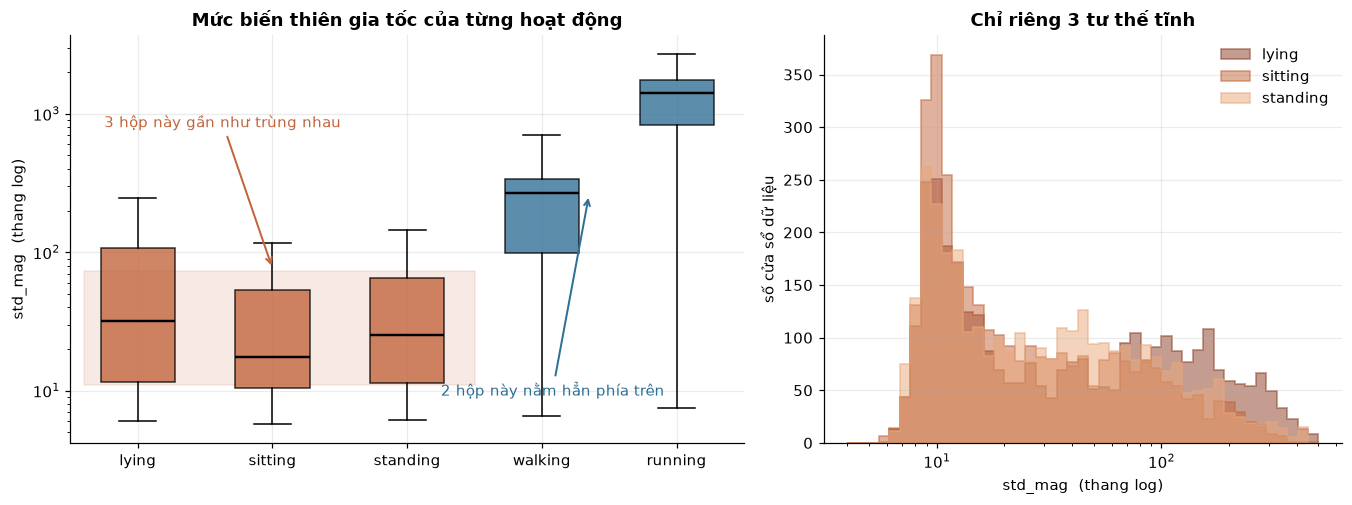

median std_mag từng hoạt động:
label
lying            31.9
sitting          17.6
standing         25.3
walking         269.1
running        1410.2


In [3]:
STATIC = ["lying", "sitting", "standing"]
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12.4, 4.7),
                               gridspec_kw={"width_ratios": [1.3, 1]})

# --- Left: all five activities, log scale so a 100x range still fits on one axis ---
data = [df.loc[df["label"] == a, "std_mag"].values for a in ACTS_5CLASS]
bp = axL.boxplot(data, tick_labels=ACTS_5CLASS, patch_artist=True, showfliers=False,
                 widths=0.55, medianprops=dict(color="black", linewidth=1.6))
for patch, a in zip(bp["boxes"], ACTS_5CLASS):
    patch.set_facecolor(COLOR[a]); patch.set_alpha(0.78)

# Band = where the middle 50% of all static rows sit, drawn only under the static
# boxes so it cannot be misread as covering walking/running too.
static_vals = df.loc[df["label"].isin(STATIC), "std_mag"]
lo, hi = static_vals.quantile(0.25), static_vals.quantile(0.75)
axL.axhspan(lo, hi, xmin=0.02, xmax=0.60, color=C_STATIC, alpha=0.13, zorder=0)

axL.set_yscale("log")
axL.set_ylabel("std_mag  (thang log)")
axL.set_title("Mức biến thiên gia tốc của từng hoạt động")
axL.annotate("3 hộp này gần như trùng nhau", xy=(2, hi * 1.05), xytext=(0.75, hi * 11),
             fontsize=9.5, color=C_STATIC,
             arrowprops=dict(arrowstyle="->", color=C_STATIC, lw=1.3))
axL.annotate("2 hộp này nằm hẳn phía trên", xy=(4.35, 260), xytext=(3.25, 9.2),
             fontsize=9.5, color=C_DYNAMIC,
             arrowprops=dict(arrowstyle="->", color=C_DYNAMIC, lw=1.3))

# --- Right: only the three static postures, as distributions rather than summaries ---
bins  = np.logspace(np.log10(4), np.log10(500), 46)
tones = {"lying": "#8C3B22", "sitting": "#C2643B", "standing": "#E9A97B"}
for a in STATIC:
    axR.hist(df.loc[df["label"] == a, "std_mag"], bins=bins, histtype="stepfilled",
             alpha=0.5, label=a, color=tones[a], edgecolor=tones[a], linewidth=1.2)
axR.set_xscale("log")
axR.set_xlabel("std_mag  (thang log)"); axR.set_ylabel("số cửa sổ dữ liệu")
axR.set_title("Chỉ riêng 3 tư thế tĩnh")
axR.legend(frameon=False, fontsize=9.5)
plt.tight_layout(); plt.show()

print("median std_mag từng hoạt động:")
print(df.groupby("label")["std_mag"].median().reindex(ACTS_5CLASS).to_string(
    float_format=lambda v: f"{v:10.1f}"))

**Đọc biểu đồ trái:** trục dọc là thang log, mỗi vạch là gấp 10 lần. Ba hộp màu cam
(nằm/ngồi/đứng) chồng lên nhau gần như hoàn toàn. Hai hộp màu xanh (đi bộ/chạy) nằm hẳn
ở tầng trên — trung vị cách nhóm tĩnh khoảng 10 đến 60 lần.

**Đọc biểu đồ phải:** phóng to riêng 3 tư thế tĩnh, vẽ nguyên phân phối thay vì tóm tắt.
Ba đường gần như đè lên nhau. Muốn tách được 3 lớp này thì phải cắt được một ngưỡng trên
trục ngang — nhìn hình là thấy không có chỗ nào cắt được.

Cần nói cho chính xác: đuôi (râu) của đi bộ/chạy vẫn thò xuống chạm vùng tĩnh — tức là
vẫn có những cửa sổ 2.4 giây lúc đi bộ mà cổ tay gần như đứng yên. Đó chính là lý do
recall của walking chỉ đạt ~0.63 chứ không phải gần 1.0.

Đây chính là kết quả 5 lớp sẽ ra: model sẽ giỏi ở hai lớp xanh và lẫn lộn ba lớp cam.
Phần còn lại của notebook xác nhận điều đó bằng số.

---
## Bước 3 — Cách đánh giá: LOGO-CV (bỏ ra một người)

Nếu chia dữ liệu ngẫu nhiên theo dòng, các cửa sổ liền kề của **cùng một người** sẽ nằm
ở cả tập huấn luyện lẫn tập kiểm tra. Model chỉ cần nhớ đặc điểm riêng của người đó là
đã đoán đúng, và điểm số sẽ cao giả tạo.

**LOGO-CV** chặn lỗ hổng đó: lần lượt bỏ hẳn một người ra, huấn luyện trên 17 người còn
lại, kiểm tra trên người bị bỏ ra. Lặp đủ 18 vòng. Điểm báo cáo là trung bình 18 vòng —
tức là ước lượng cho **một người dùng mới mà model chưa từng gặp**.

In [4]:
def run_logocv(X, y, groups, class_labels, title):
    """One shared runner for both label groupings, so the two results below differ
    only by the target column -- never by procedure."""
    logo = LeaveOneGroupOut()
    fold_acc, all_true, all_pred = [], [], []
    for train_idx, test_idx in logo.split(X, y, groups):
        clf = make_model()
        clf.fit(X[train_idx], y[train_idx])
        pred = clf.predict(X[test_idx])
        fold_acc.append((groups[test_idx][0], accuracy_score(y[test_idx], pred)))
        all_true.extend(y[test_idx]); all_pred.extend(pred)

    cm = confusion_matrix(all_true, all_pred, labels=class_labels)
    recall = {a: (cm[i][i] / cm[i].sum() if cm[i].sum() else np.nan)
              for i, a in enumerate(class_labels)}
    mean_acc = float(np.mean([a for _, a in fold_acc]))

    print(f"=== {title} ===")
    print(f"Accuracy trung bình qua {len(fold_acc)} vòng: {mean_acc:.3f}\n")
    print("Recall từng lớp (tỉ lệ bắt đúng khi lớp đó thực sự xảy ra):")
    for a, r in recall.items():
        bar = "█" * int(round(r * 40))
        print(f"  {a:>10s}  {r:.3f}  {bar}")
    return dict(mean_acc=mean_acc, folds=dict(fold_acc), cm=cm, recall=recall,
                labels=class_labels)


res5 = run_logocv(X, df["label"].values, groups, ACTS_5CLASS, "5 lớp")

=== 5 lớp ===
Accuracy trung bình qua 18 vòng: 0.548

Recall từng lớp (tỉ lệ bắt đúng khi lớp đó thực sự xảy ra):
       lying  0.284  ███████████
     sitting  0.469  ███████████████████
    standing  0.551  ██████████████████████
     walking  0.646  ██████████████████████████
     running  0.782  ███████████████████████████████


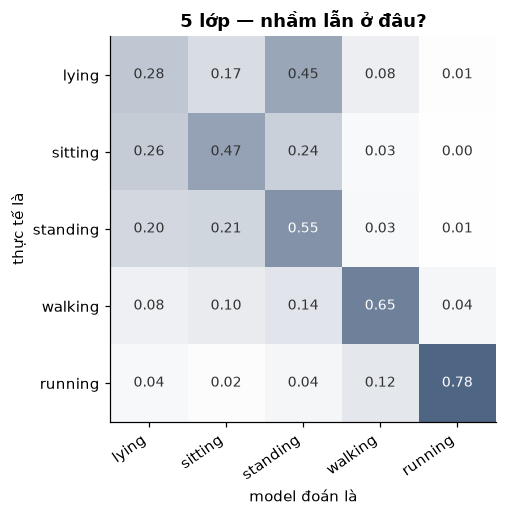

In [5]:
def plot_cm(res, ax, title):
    """Row-normalised confusion matrix: each row shows where that true class went."""
    cm   = res["cm"]
    norm = cm / cm.sum(axis=1, keepdims=True)
    cmap = LinearSegmentedColormap.from_list("acc", ["#FFFFFF", C_ACCENT])
    ax.imshow(norm, cmap=cmap, vmin=0, vmax=1)

    labs = res["labels"]
    ax.set_xticks(range(len(labs))); ax.set_xticklabels(labs, rotation=35, ha="right")
    ax.set_yticks(range(len(labs))); ax.set_yticklabels(labs)
    ax.set_xlabel("model đoán là"); ax.set_ylabel("thực tế là")
    ax.set_title(title); ax.grid(False)
    for i in range(len(labs)):
        for j in range(len(labs)):
            ax.text(j, i, f"{norm[i, j]:.2f}", ha="center", va="center", fontsize=9,
                    color="white" if norm[i, j] > 0.5 else "#333333")


fig, ax = plt.subplots(figsize=(5.4, 4.8))
plot_cm(res5, ax, "5 lớp — nhầm lẫn ở đâu?")
plt.tight_layout(); plt.show()

**Đọc biểu đồ:** mỗi hàng cộng lại bằng 1 — hàng cho biết khi hoạt động đó thực sự
xảy ra thì model đoán thành gì.

Toàn bộ ô đậm nằm gọn trong khối 3×3 góc trên bên trái: nằm/ngồi/đứng liên tục bị đoán
nhầm sang nhau (nặng nhất là **nằm → đứng**). Hai hàng dưới cùng (đi bộ, chạy) thì ô đậm
nằm đúng trên đường chéo.

Nói cách khác: model không "kém đều" — nó **hỏng đúng ở một chỗ**, và đúng ở chỗ mà
biểu đồ Bước 2 đã dự báo trước.

---
## Bước 4 — Giải pháp: gộp 3 tư thế tĩnh thành một lớp

Vì 4 đặc trưng **về mặt toán học không thể** phân biệt 3 tư thế tĩnh, ta gộp chúng
thành một lớp `stationary` và đo lại.

Quan trọng: **giữ nguyên tuyệt đối mọi thứ khác** — cùng model, cùng tham số, cùng dữ
liệu, cùng giao thức LOGO-CV. Chỉ đổi đúng một thứ là cột nhãn. Nhờ vậy chênh lệch
quan sát được quy về đúng một nguyên nhân, chứ không lẫn với thay đổi nào khác.

=== 3 lớp ===
Accuracy trung bình qua 18 vòng: 0.853

Recall từng lớp (tỉ lệ bắt đúng khi lớp đó thực sự xảy ra):
  stationary  0.951  ██████████████████████████████████████
     walking  0.632  █████████████████████████
     running  0.777  ███████████████████████████████


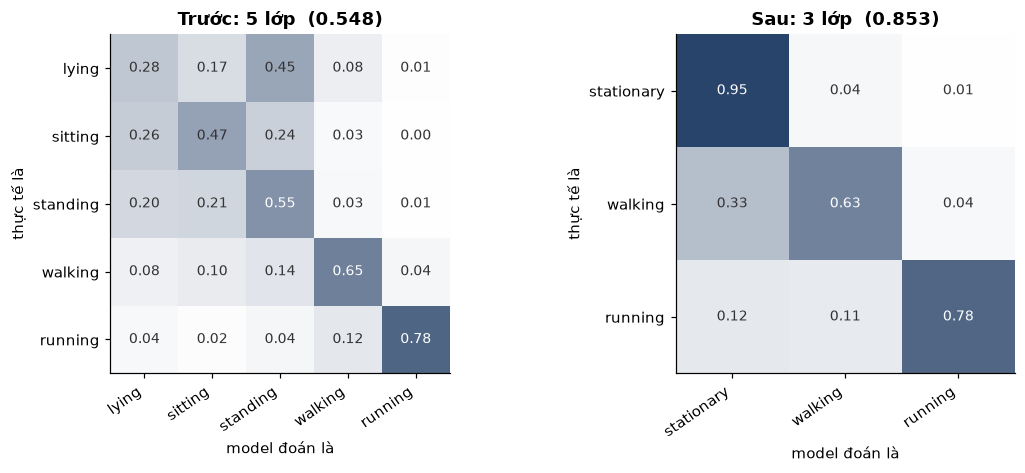

In [6]:
res3 = run_logocv(X, df["activity_group"].values, groups, ACTS_3CLASS, "3 lớp")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4))
plot_cm(res5, axes[0], "Trước: 5 lớp  (0.548)")
plot_cm(res3, axes[1], "Sau: 3 lớp  (0.853)")
plt.tight_layout(); plt.show()

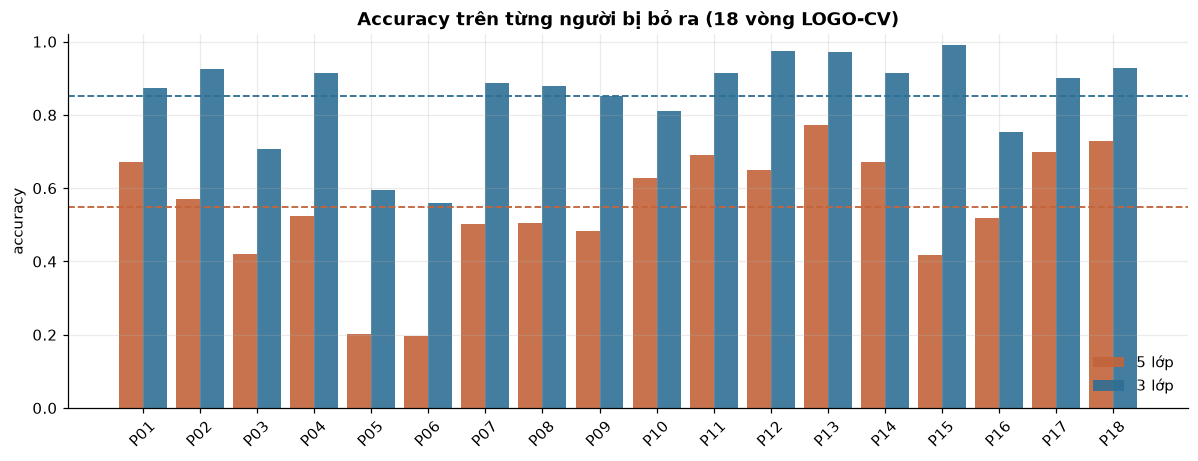

5 lớp — thấp nhất 0.196, cao nhất 0.773
3 lớp — thấp nhất 0.559, cao nhất 0.991


In [7]:
# Per-participant view: a mean can hide that some people are classified far worse
# than others, which matters because each fold is a different held-out person.
pids = sorted(res5["folds"])
a5   = [res5["folds"][p] for p in pids]
a3   = [res3["folds"][p] for p in pids]
x    = np.arange(len(pids))

fig, ax = plt.subplots(figsize=(11, 4.3))
ax.bar(x - 0.21, a5, 0.42, label="5 lớp", color=C_STATIC,  alpha=0.9)
ax.bar(x + 0.21, a3, 0.42, label="3 lớp", color=C_DYNAMIC, alpha=0.9)
ax.axhline(np.mean(a5), color=C_STATIC,  ls="--", lw=1.2)
ax.axhline(np.mean(a3), color=C_DYNAMIC, ls="--", lw=1.2)
ax.set_xticks(x); ax.set_xticklabels(pids, rotation=45)
ax.set_ylabel("accuracy"); ax.set_ylim(0, 1.02)
ax.set_title("Accuracy trên từng người bị bỏ ra (18 vòng LOGO-CV)")
ax.legend(loc="lower right", frameon=False)
plt.tight_layout(); plt.show()

print(f"5 lớp — thấp nhất {min(a5):.3f}, cao nhất {max(a5):.3f}")
print(f"3 lớp — thấp nhất {min(a3):.3f}, cao nhất {max(a3):.3f}")

**Đọc biểu đồ:** hầu như người nào cột xanh cũng cao hơn cột cam — việc gộp lớp giúp
đều tay chứ không phải chỉ ăn may ở vài người.

Nhưng khoảng dao động giữa người với người rất rộng (3 lớp: từ 0.559 đến 0.991). Điều
này gợi ý phần accuracy còn thiếu đến từ **khác biệt giữa từng người** — sải chân, nhịp
bước, cách vung tay — chứ không phải model thiếu dữ liệu. Đây là căn cứ cho đề xuất
"cá nhân hoá ngưỡng cho người dùng mới" ở phần cuối báo cáo.

---
## Bước 5 — 0.853 có thật sự tốt không?

Một con số accuracy không có ý nghĩa cho đến khi biết **model ngu nhất** được bao nhiêu
trên cùng dữ liệu. Model ngu nhất ở đây là loại bỏ qua hoàn toàn cảm biến, luôn đoán
lớp đông nhất.

Điểm mấu chốt: hai bài toán **không có cùng mốc sàn**. Gộp 3 tư thế tĩnh tạo ra một lớp
chiếm 3/5 dữ liệu, nên chỉ cần đoán "stationary" cho mọi trường hợp đã đúng gần 60%.
Vì vậy so thẳng 0.548 với 0.853 là **phóng đại** mức cải thiện.

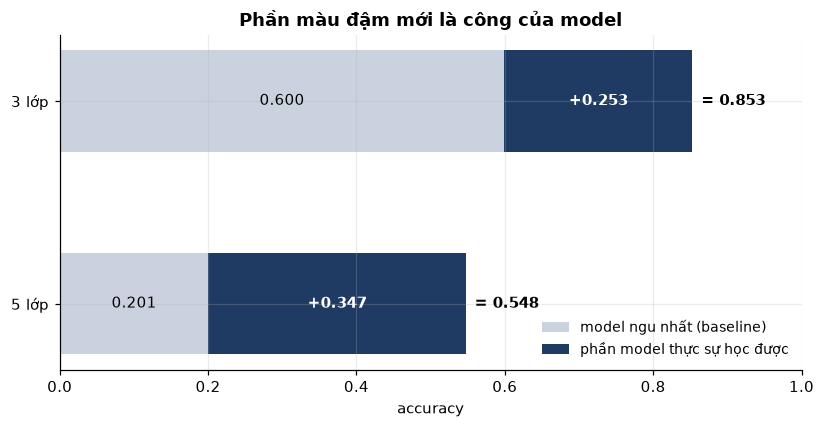

5 lớp: baseline 0.201 → 0.548  (hơn baseline +0.347)
3 lớp: baseline 0.600 → 0.853  (hơn baseline +0.253)


In [8]:
base5 = df["label"].value_counts().max() / len(df)
base3 = df["activity_group"].value_counts().max() / len(df)
rows  = [("5 lớp", base5, res5["mean_acc"]), ("3 lớp", base3, res3["mean_acc"])]

fig, ax = plt.subplots(figsize=(7.6, 4.0))
y = np.arange(2)
ax.barh(y, [b for _, b, _ in rows], 0.5, color="#C9D2DE", label="model ngu nhất (baseline)")
ax.barh(y, [a - b for _, b, a in rows], 0.5, left=[b for _, b, _ in rows],
        color=C_ACCENT, label="phần model thực sự học được")
for i, (name, b, a) in enumerate(rows):
    ax.text(b / 2, i, f"{b:.3f}", ha="center", va="center", fontsize=9.5)
    ax.text(b + (a - b) / 2, i, f"+{a - b:.3f}", ha="center", va="center",
            fontsize=10, color="white", fontweight="bold")
    ax.text(a + 0.012, i, f"= {a:.3f}", va="center", fontsize=10, fontweight="bold")

ax.set_yticks(y); ax.set_yticklabels([n for n, _, _ in rows])
ax.set_xlim(0, 1.0); ax.set_xlabel("accuracy")
ax.set_title("Phần màu đậm mới là công của model")
ax.legend(loc="lower right", frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

print(f"5 lớp: baseline {base5:.3f} → {res5['mean_acc']:.3f}  (hơn baseline +{res5['mean_acc']-base5:.3f})")
print(f"3 lớp: baseline {base3:.3f} → {res3['mean_acc']:.3f}  (hơn baseline +{res3['mean_acc']-base3:.3f})")

**Kết luận ngược với trực giác:** bài toán 3 lớp cho accuracy tuyệt đối cao hơn và
**dùng được hơn**, nhưng phần "model thực sự học được" (+0.254) lại **nhỏ hơn** so với
bài toán 5 lớp (+0.347). Cải thiện là thật, nhưng nhỏ hơn con số +0.305 thô gợi ý.

---
## Bước 6 — Model học được quy tắc gì?

Decision tree không phải hộp đen: vẽ ra là đọc được từng quy tắc. Dưới đây là 3 tầng
đầu của cây 3 lớp (cây thật sâu 5 tầng, cắt bớt cho dễ nhìn).

Cách đọc: mỗi ô hỏi một câu về một đặc trưng. Đúng thì đi nhánh trái, sai thì đi nhánh
phải. Ô màu đậm là nơi model đã khá chắc chắn về câu trả lời.

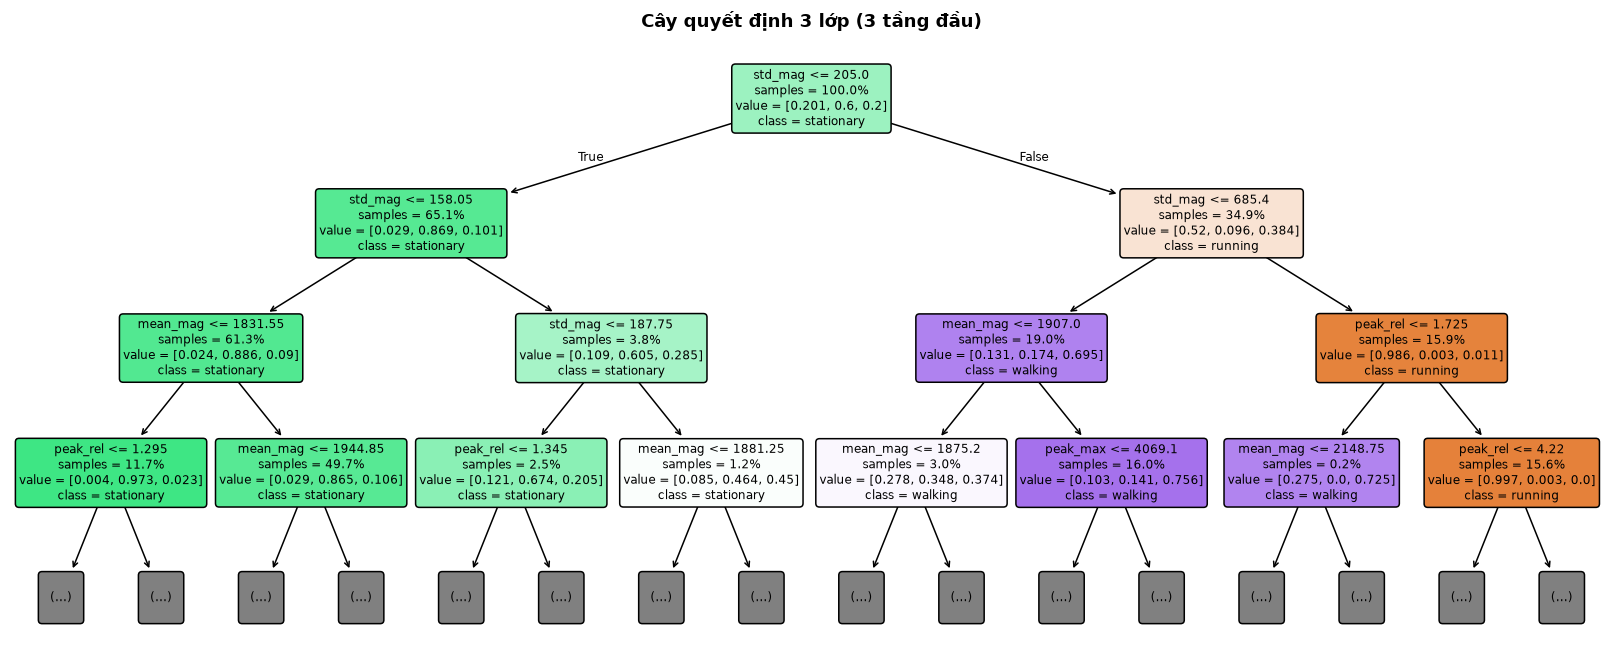

Đặc trưng nào được model dùng nhiều nhất:
std_mag    0.925
mean_mag   0.047
peak_rel   0.015
peak_max   0.013


In [9]:
tree3 = make_model().fit(X, df["activity_group"].values)

fig, ax = plt.subplots(figsize=(15, 6.2))
plot_tree(tree3, feature_names=FEATURES, class_names=list(tree3.classes_),
          max_depth=3, filled=True, rounded=True, impurity=False,
          proportion=True, fontsize=8, ax=ax)
ax.set_title("Cây quyết định 3 lớp (3 tầng đầu)")
plt.tight_layout(); plt.show()

imp = pd.Series(tree3.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("Đặc trưng nào được model dùng nhiều nhất:")
print(imp.to_string(float_format=lambda v: f"{v:.3f}"))

Đọc được ngay từ cây: câu hỏi đầu tiên model đặt ra là về `std_mag` — đúng cái đặc
trưng mà biểu đồ Bước 2 cho thấy tách được nhóm tĩnh khỏi nhóm động. Model tự tìm ra
đúng ranh giới mà phân tích ban đầu đã dự đoán.

---
## Bước 7 — Xuất model đem nạp lên thiết bị

Model đem triển khai là bản **5 lớp huấn luyện trên toàn bộ 18 người** (không phải model
của một vòng LOGO-CV nào — các vòng đó chỉ dùng để báo cáo accuracy trung thực).

Bản 3 lớp ở trên là để so sánh và giải thích, không phải model thứ hai đem nạp.

In [10]:
final_model = make_model().fit(X, df["label"].values)
os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)
joblib.dump({"model": final_model, "features": FEATURES,
             "classes": list(final_model.classes_)}, OUT_PATH)
print(f"Đã lưu model (huấn luyện trên {df['participant_id'].nunique()} người) → {OUT_PATH}")

Đã lưu model (huấn luyện trên 18 người) → models/activity_classifier.pkl


---
## Tóm tắt và giới hạn

| | 5 lớp | 3 lớp |
| :--- | ---: | ---: |
| Accuracy (LOGO-CV, 18 người) | 0.548 | 0.853 |
| Baseline của chính bài toán đó | 0.201 | 0.599 |
| Phần model thực sự học được | +0.347 | +0.254 |

**Notebook này KHÔNG chứng minh:**

- Không chứng minh model phân biệt được nằm/ngồi/đứng — ngược lại, nó chứng minh bộ đặc
  trưng hiện tại **không thể** làm điều đó, và chỉ ra nguyên nhân.
- Không đo độ chính xác nhịp tim (thuộc subsystem khác).
- Không đo độ trễ hay điện năng khi chạy thật trên thiết bị.
- Con số 0.853 là ước lượng theo LOGO-CV trên 18 người, **không phải** kết quả thử
  nghiệm thực tế trên người dùng mới ngoài đời.

**Muốn cải thiện tiếp** thì phải bổ sung một kênh đo *mới* (con quay hồi chuyển đã có
sẵn trên phần cứng nhưng chưa đọc), chứ không phải chỉnh model — xem phần 5 của báo cáo.